# count inferred vs. true migrations 

#### import packages

In [1]:
import os

import itertools
from itertools import combinations

import pandas as pd 
import csv 
import numpy as np 

import matplotlib.pyplot as plt 
%matplotlib inline 

import seaborn as sns 

In [2]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
import tskit
from Bio import SeqIO, AlignIO

In [4]:
import glob
from collections import Counter

In [5]:
import json

In [6]:
from Bio import Phylo
from io import StringIO

### import tree sequences

In [7]:
ts_dir = "rerun/trees/" 
# tss = sorted(os.listdir(ts_dir))
# tss[0:5]

In [8]:
trees_dir = "rerun/results/" 
# trees_files = sorted(os.listdir(trees_dir))
# trees = [item for item in trees_files if ".nwk" in item]
# trees[0:5]

In [9]:
traits_dir = "rerun/results/"

### import inferred locations

In [10]:
# sim_locations_dir = "rerun/locations" 
# sim_locations = sorted(os.listdir(sim_locations_dir))#[1:]

# inf_locations_dir = "rerun/locations" 
# inf_locations = sorted(os.listdir(inf_locations_dir))#[1:]

# ctrl_locations_dir = "rerun/locations" 
# ctrl_locations = sorted(os.listdir(ctrl_locations_dir))#[1:]

### import inferred states

In [11]:
states_dir = "out/" 

### import scores

In [17]:
scores_dir = "scores/" 
scores = sorted(os.listdir(scores_dir))

In [19]:
list = [score.split("_") for score in scores]
type = [item[0] for item in list]
pm = [item[3][2:] for item in list]
mr = [item[4][2:] for item in list]
seed = [item[5][4:-4] for item in list]

In [20]:
runs = pd.DataFrame(scores, columns= ["path"])
runs['type'] = type
runs['pm'] = pm 
runs['mr'] = mr 
runs['seed'] = seed 
## find unique combinations of pm/mr (i.e. identify reps) 
runs['rep'] = runs.groupby(['type', 'pm', 'mr']).cumcount() + 1
runs['run'] = runs['path'].str.replace(r'^.*ss_', 'ss_', regex=True).str[:-4]
runs['scores'] = "scores/" + runs['path']
runs = runs.drop(columns = ['path']) 
runs['metadata'] =  "rerun/metadata/sim_" + runs['run'] + ".tsv"

In [21]:
runs

,type,pm,mr,seed,rep,run,scores,metadata
0,control,5.000e-2,5.000e-4,15,1,ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15,scores/control_ss_mu2.500e-8_pm5.000e-2_mr5.00...,rerun/metadata/sim_ss_mu2.500e-8_pm5.000e-2_mr...
1,inf,5.000e-2,5.000e-4,15,1,ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15,scores/inf_ss_mu2.500e-8_pm5.000e-2_mr5.000e-4...,rerun/metadata/sim_ss_mu2.500e-8_pm5.000e-2_mr...
2,sim,5.000e-2,5.000e-4,15,1,ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15,scores/sim_ss_mu2.500e-8_pm5.000e-2_mr5.000e-4...,rerun/metadata/sim_ss_mu2.500e-8_pm5.000e-2_mr...


In [32]:
def add_locs(row): 
    if row['type'] == 'control':
        return ctrl_locations_dir + "control_" + row['run'] + ".csv"

    if row['type'] == 'sim':
        return sim_locations_dir + "sim_" + row['run'] + ".csv"

    if row['type'] == 'inf':
        return inf_locations_dir + "inf_" + row['run'] + ".csv"


def add_trees(row): 
    if row['type'] == 'control':
        return trees_dir + "sim_" + row['run'] + ".nwk"

    if row['type'] == 'sim':
        return ts_dir + "sim_" + row['run'] + ".trees"

    if row['type'] == 'inf':
        return ts_dir + "inf_" + row['run'] + ".trees"


def add_states(row): 
    if row['type'] == 'control': ##traits 
        return traits_dir + "sim_" + row['run'] + "_traits.json"

    if row['type'] == 'sim':
        #return states_dir + "/"  + "sim_" + row['run'] + ".states.tsv"
        return "sim.states.tsv"

    if row['type'] == 'inf':
        #return states_dir +  "/"  + "inf_" + row['run'] + ".states.tsv"
        return "inf.states.tsv"

In [33]:
runs['locations'] = runs.apply(add_locs, axis=1)
runs['trees'] = runs.apply(add_trees, axis=1)
runs['states'] = runs.apply(add_states, axis=1)

In [34]:
runs

,type,pm,mr,seed,rep,run,scores,metadata,locations,trees,states
0,control,5.000e-2,5.000e-4,15,1,ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15,scores/control_ss_mu2.500e-8_pm5.000e-2_mr5.00...,rerun/metadata/sim_ss_mu2.500e-8_pm5.000e-2_mr...,rerun/locationscontrol_ss_mu2.500e-8_pm5.000e-...,rerun/results/sim_ss_mu2.500e-8_pm5.000e-2_mr5...,rerun/results/sim_ss_mu2.500e-8_pm5.000e-2_mr5...
1,inf,5.000e-2,5.000e-4,15,1,ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15,scores/inf_ss_mu2.500e-8_pm5.000e-2_mr5.000e-4...,rerun/metadata/sim_ss_mu2.500e-8_pm5.000e-2_mr...,rerun/locationsinf_ss_mu2.500e-8_pm5.000e-2_mr...,rerun/trees/inf_ss_mu2.500e-8_pm5.000e-2_mr5.0...,inf.states.tsv
2,sim,5.000e-2,5.000e-4,15,1,ss_mu2.500e-8_pm5.000e-2_mr5.000e-4_seed15,scores/sim_ss_mu2.500e-8_pm5.000e-2_mr5.000e-4...,rerun/metadata/sim_ss_mu2.500e-8_pm5.000e-2_mr...,rerun/locationssim_ss_mu2.500e-8_pm5.000e-2_mr...,rerun/trees/sim_ss_mu2.500e-8_pm5.000e-2_mr5.0...,sim.states.tsv


### record true migration counts 
from A->B, B->C, etc. 

In [35]:
## for tree sequences only i.e. 
## runs[runs['type'] == 'sim']] 

def count_true_migrations(runs_df):
    records = []

    for idx, row in runs_df.iterrows():
        # get metadata 
        run_type = row['type']
        run_pm = row['pm']
        run_mr = row['mr']
        run_seed = row['seed']

        # get paths 
        tree_path = row['trees']
    
        print(f"curr: type={run_type}, pm={run_pm}, mr={run_mr}, seed={run_seed}")
    
        migration_counts = Counter()
        ts = tskit.load(tree_path)
        migrations = ts.tables.migrations
    
        for mig in migrations:
            src = mig.source
            dest = mig.dest
            migration_counts[(src, dest)] += 1
    
        for (src, dest), count in migration_counts.items():
                records.append({
                    'type': 'true',
                    'pm': run_pm,
                    'mr': run_mr,
                    'seed': run_seed,
                    'source': src,
                    'dest': dest,
                    'count': count
                })

    # as df 
    res = pd.DataFrame(records)
    
    return res

In [26]:
true_res = count_true_migrations(runs[runs['type']=='sim'])

curr: type=sim, pm=5.000e-2, mr=5.000e-4, seed=15


In [27]:
true_res

,type,pm,mr,seed,source,dest,count
0,true,5.000e-2,5.000e-4,15,2,1,13
1,true,5.000e-2,5.000e-4,15,1,0,15
2,true,5.000e-2,5.000e-4,15,2,0,57
3,true,5.000e-2,5.000e-4,15,1,2,28
4,true,5.000e-2,5.000e-4,15,0,2,43
5,true,5.000e-2,5.000e-4,15,0,1,28


### record inferred migration counts 
for simulated network, inferred network, and tree

In [36]:
## for tree sequences only i.e. 
## runs[runs['type'] != 'control']] 

def count_network_migrations(runs_df):
    records = []

    # iterate through runs df 
    for idx, row in runs_df.iterrows():
        # get metadata 
        run_type = row['type']
        run_pm = row['pm']
        run_mr = row['mr']
        run_seed = row['seed']
        
        # get paths 
        tree_path = row['trees']
        states_path = row['states']

        print(f"curr: type={run_type}, pm={run_pm}, mr={run_mr}, seed={run_seed}")

        # load states 
        states_df = pd.read_csv(states_path, sep='\t')
        states_df['NODE_NAME'] = states_df['NODE_NAME'].astype(int)
        states_df['TREE_INDEX'] = states_df['TREE_INDEX'].astype(int)
        
        # map index/node -> state
        state_map = states_df.set_index(['TREE_INDEX', 'NODE_NAME'])['STATE'].to_dict()

        # count unique migrations (unique edges) 
        migration_counts = Counter()
        ts = tskit.load(tree_path)
        
        for edge in ts.edges():
            parent = edge.parent
            child = edge.child
            
            # find first tree index where edge appears
            tree_idx = ts.at(edge.left).index
            # get parent/child states 
            parent_state = state_map.get((tree_idx, parent))
            child_state = state_map.get((tree_idx, child))
            
            # if state change, counter++ 
            if (parent_state != child_state):
                migration_counts[(parent_state, child_state)] += 1

        # append to records
        for (src, dest), count in migration_counts.items():
            records.append({
                'type': run_type,
                'pm': run_pm,
                'mr': run_mr,
                'seed': run_seed,
                'source': src,
                'dest': dest,
                'count': count
            })

    # as df 
    res = pd.DataFrame(records)
    
    return res

In [37]:
def get_location_from_traits(traits_file): 
    
    with open(traits_file, 'r') as file: 
        data = json.load(file) 
   
    dict = data['nodes']
    subdict = {key: value for (key, value) in dict.items() if 'N' in key}
    subdict = pd.DataFrame(subdict).transpose()
    
    pops = pd.json_normalize(subdict['population_confidence']).set_index(subdict.index)
    res = subdict.join(pops).drop(columns=['population_confidence'])
    res[['1', '2', '3']] = res[['1', '2', '3']].fillna(0)
    res['node'] = res.index
    return res

In [38]:
## for trees only i.e. 
## runs[runs['type'] == 'control']] 

def count_tree_migrations(runs_df): 

    records = []

    # iterate through runs df 
    for idx, row in runs_df.iterrows():
        # get metadata 
        run_type = row['type']
        run_pm = row['pm']
        run_mr = row['mr']
        run_seed = row['seed']
        
        # get paths 
        tree_path = row['trees']
        traits_path = row['states']
        metadata_path = row['metadata'] 

        #print(f"curr: type={run_type}, pm={run_pm}, mr={run_mr}, seed={run_seed}")

        # import traits, location files, tip metadata 
        traits = get_location_from_traits(traits_path)
        
        
        meta = pd.read_csv(metadata_path, sep='\t') 
        meta['strain'] = meta['strain'].astype(str)
        meta['population'] = meta['population'].astype(str)
        
        nodedict = dict(zip(traits.node,traits.population))
        tipdict = dict(zip(meta.strain,meta.population))
        popdict = nodedict | tipdict

        ## read in iqtree
        tree = Phylo.read(tree_path, format = "newick") 
        
        for clade in tree.find_clades():
            clade.population = popdict[clade.name]

        parents = {}
        for parent in tree.find_clades(order="level"):
            for child in parent.clades:
                parents[child] = parent

        migration_counts = Counter()
        
        for clade in tree.find_clades():
            if clade in parents:
                parent = parents[clade]
                if hasattr(parent, 'population') and hasattr(clade, 'population'):
                    if parent.population != clade.population:
                        migration_counts[getattr(parent, 'population'), getattr(clade, 'population')] += 1
                
                # parent_pop = getattr(parent, 'population', None)
                # child_pop = getattr(clade, 'population', None)
                
                # # record state changes 
                # if parent_pop and child_pop and (parent_pop != child_pop):
                #     migration_counts[(parent_pop, child_pop)] += 1

        # add to records 
        for (src, dest), count in migration_counts.items():
            records.append({
                'type': run_type,
                'pm': run_pm,
                'mr': run_mr,
                'seed': run_seed,
                'source': str(int(src)-1),
                'dest': str(int(dest)-1),
                'count': count
            })

    # as df 
    res = pd.DataFrame(records)
    
    return res

In [39]:
network_res = count_network_migrations(runs[runs['type']!='control'])

curr: type=inf, pm=5.000e-2, mr=5.000e-4, seed=15
curr: type=sim, pm=5.000e-2, mr=5.000e-4, seed=15


In [40]:
tree_res = count_tree_migrations(runs[runs['type']=='control'])

In [41]:
migrations = pd.concat([true_res, network_res, tree_res])

In [42]:
# route label
migrations['migration_route'] = migrations['source'].astype(str) + " → " + migrations['dest'].astype(str)

# sort routes
migrations = migrations.sort_values("migration_route")

# reorder type
migrations["type"] = pd.Categorical(migrations["type"], categories=['true', 'sim', 'inf', 'control'], ordered=True)

migrations['mr'] = pd.to_numeric(migrations['mr'])

In [43]:
migrations

,type,pm,mr,seed,source,dest,count,migration_route
5,true,5.000e-2,0.0005,15,0,1,28,0 → 1
1,control,5.000e-2,0.0005,15,0,1,1,0 → 1
2,inf,5.000e-2,0.0005,15,0,1,13,0 → 1
8,sim,5.000e-2,0.0005,15,0,1,12,0 → 1
4,true,5.000e-2,0.0005,15,0,2,43,0 → 2
4,inf,5.000e-2,0.0005,15,0,2,33,0 → 2
0,control,5.000e-2,0.0005,15,0,2,4,0 → 2
7,sim,5.000e-2,0.0005,15,0,2,29,0 → 2
3,inf,5.000e-2,0.0005,15,1,0,2,1 → 0
1,true,5.000e-2,0.0005,15,1,0,15,1 → 0


# plot results (single run) 

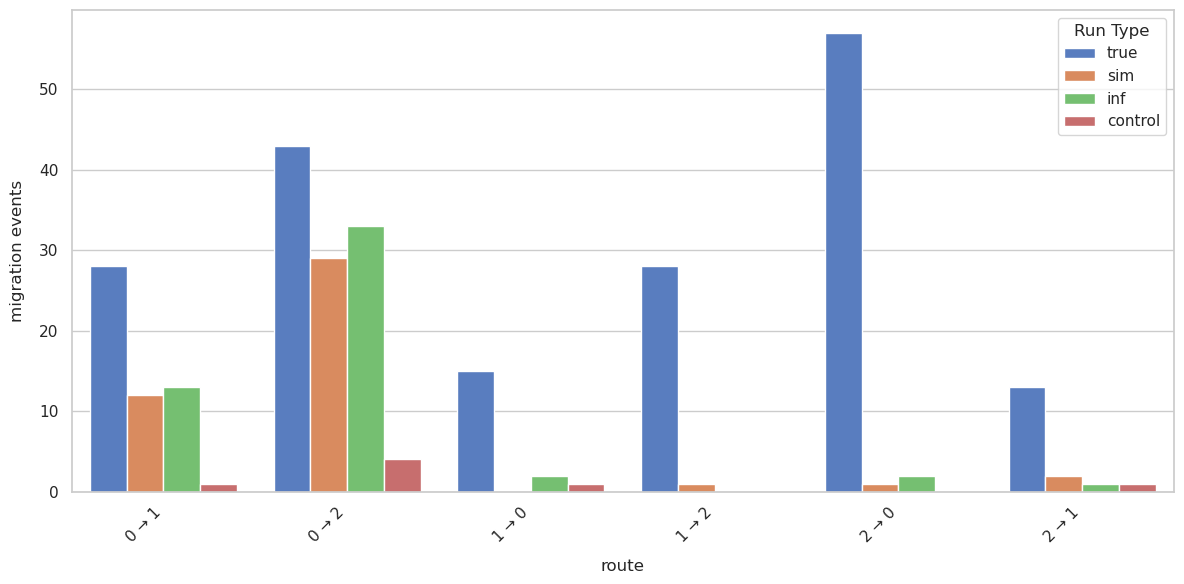

In [44]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=migrations,
    x='migration_route',
    y='count',
    hue='type',
    #errorbar='sd',    
    palette='muted'
)

plt.xlabel('route', fontsize=12, labelpad=10)
plt.ylabel('migration events', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right') 
plt.legend(title='Run Type', frameon=True)

plt.tight_layout()
plt.show()

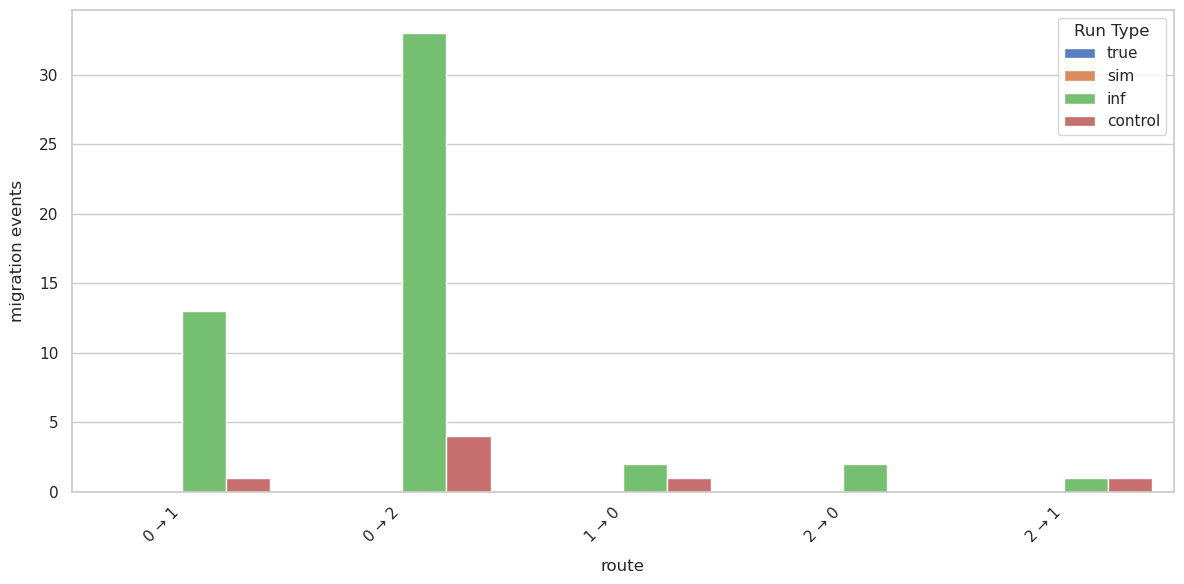

In [46]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=migrations[(migrations['type'] != "true")& (migrations['type'] != "sim")],
    x='migration_route',
    y='count',
    hue='type',
    #errorbar='sd',    
    palette='muted'
)

plt.xlabel('route', fontsize=12, labelpad=10)
plt.ylabel('migration events', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right') 
plt.legend(title='Run Type', frameon=True)

plt.tight_layout()
plt.show()

/loc/scratch/53915357/ipykernel_7417/228715703.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  g = sns.catplot(
/app/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


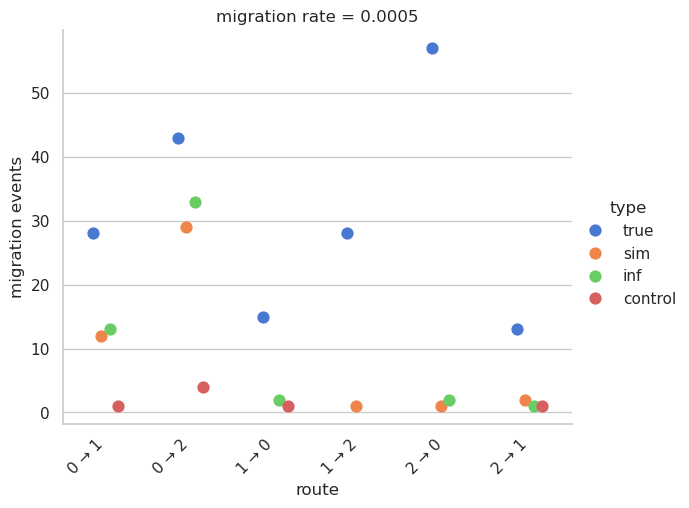

In [47]:
g = sns.catplot(
    data=migrations,
    kind="point",      
    x="migration_route",
    y="count",
    col="mr",           
    hue="type",         
    errorbar="sd",      
    join=False,         
    dodge=0.3,          
    palette="muted",
    height=5,
    aspect=1.2
)

g.set_xticklabels(rotation=45, horizontalalignment='right')
g.set_axis_labels("route", "migration events")
g.set_titles("migration rate = {col_name}")

plt.show()
